In [1]:
import numpy as np
import pandas as pd
import json
from itertools import combinations
import itertools
import random
from collections import defaultdict
import os
import shutil
import ast
from matplotlib import pyplot as plt
import pickle
import json

In [2]:
def DownloadAndRenaming(path):
    df = pd.read_csv(path)
    df = df.rename(columns={"Unnamed: 0": "Gene"})
    return df

In [4]:
# Read in the datasets
cancer_complexes = pd.read_excel('/Users/guowanyi/Desktop/fall_2025/Louis_Vuitton/cancer_complexes_clean.xlsx', index_col = 0)
Gene_expression = DownloadAndRenaming('/Users/guowanyi/Desktop/fall_2025/Louis_Vuitton/DepMap_Trimmed/Gene_Expression_Trimmed.csv')

cancer_complexes["Representative Genes (Core Members)"] = (cancer_complexes["Representative Genes (Core Members)"].apply(ast.literal_eval))

type(cancer_complexes["Representative Genes (Core Members)"].iloc[0])

list

     Functional Category                        Complex Name  \
0  Cell-cycle regulation                Cyclin–CDK complexes   
1  Cell-cycle regulation            RB–E2F repressor complex   
2  Cell-cycle regulation     ORC–MCM pre-replication complex   
3  Cell-cycle regulation  Anaphase-Promoting Complex (APC/C)   
4  Cell-cycle regulation                     Cohesin complex   

                 Representative Genes (Core Members)  \
0  [CCND1, CCNE1, CDK1, CDK2, CDK4, CDK6, CCNA2, ...   
1               [RB1, E2F1, E2F2, E2F3, HDAC1, RBL1]   
2  [ORC1, ORC2, ORC3, ORC4, ORC5, ORC6, MCM2, MCM...   
3  [ANAPC1, ANAPC2, ANAPC3, ANAPC4, ANAPC5, ANAPC...   
4                 [SMC1A, SMC3, RAD21, STAG1, STAG2]   

                            Major Function in Cancer  GeneCount  
0  Drive G1/S and G2/M transitions; hyperactivate...          8  
1  Controls S-phase entry; often disrupted via RB...          6  
2  DNA replication licensing; overexpressed in pr...         14  
3          Ubi

Text(0.5, 1.0, 'The distribution of gene counts in complexes')

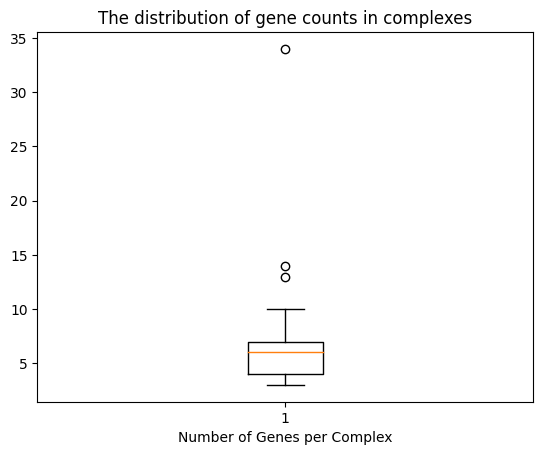

In [5]:
# Add how many number of genes are within each complex
# Let's first get an impression about the distribution of complex
cancer_complexes["GeneCount"] = cancer_complexes["Representative Genes (Core Members)"].apply(len)
print(cancer_complexes.head())

plt.boxplot(cancer_complexes["GeneCount"])
plt.xlabel("Number of Genes per Complex")
plt.title("The distribution of gene counts in complexes")

In [97]:
# Positive control generation---------

def PositiveControlGeneration(cancer_complexes):
    eachComplex_dict = {}
    complexNames = cancer_complexes["Complex Name"].tolist()

    for complex_name in complexNames:

        all_subunits = cancer_complexes.loc[
            cancer_complexes["Complex Name"] == complex_name,
            "Representative Genes (Core Members)"
        ].iloc[0]

        # Ensure it is a list of unique genes
        all_subunits = list(set(all_subunits))
        howManyGenes = len(all_subunits)

        if howManyGenes < 2:
            print(f'Warning: {complex_name} does not have enough genes!')
            continue

        random.shuffle(all_subunits)

        # Determine how many gene pairs to take
        if howManyGenes <= 10:
            numGenePair = howManyGenes // 2
        else:
            numGenePair = 5

        # Create pairs by pairing adjacent genes
        genePairList = []
        for j in range(numGenePair):
            genePairList.append([all_subunits[2*j], all_subunits[2*j + 1]])

        eachComplex_dict[complex_name] = genePairList

    return eachComplex_dict


In [98]:
# Generate let's say 10 positive controls
positive_controls = {}

for i in range(10):
    pc = PositiveControlGeneration(cancer_complexes)
    positive_controls[f"positive_control_{i+1}"] = pc



In [99]:
# Let's inspect a set
positive_controls["positive_control_1"]

{'Cyclin–CDK complexes': [['CCNE1', 'CDK4'],
  ['CCND1', 'CCNB1'],
  ['CDK2', 'CDK1'],
  ['CCNA2', 'CDK6']],
 'RB–E2F repressor complex': [['E2F1', 'RBL1'],
  ['RB1', 'HDAC1'],
  ['E2F3', 'E2F2']],
 'ORC–MCM pre-replication complex': [['MCM7', 'MCM2'],
  ['ORC6', 'MCM3'],
  ['MCM4', 'CDT1'],
  ['ORC3', 'MCM5'],
  ['ORC1', 'ORC2']],
 'Anaphase-Promoting Complex (APC/C)': [['ANAPC10', 'ANAPC3'],
  ['ANAPC9', 'ANAPC4'],
  ['ANAPC11', 'ANAPC5'],
  ['ANAPC1', 'ANAPC2'],
  ['CDC20', 'ANAPC8']],
 'Cohesin complex': [['SMC1A', 'STAG1'], ['RAD21', 'STAG2']],
 'MRN complex': [['MRE11', 'NBN']],
 'BRCA1–BARD1 complex': [['BRCA1', 'BARD1'], ['PALB2', 'RAD51']],
 'Fanconi Anemia (FA) core complex': [['FANCD2', 'FANCG'],
  ['FANCM', 'FANCA'],
  ['FANCL', 'FANCE'],
  ['FANCF', 'FANCB']],
 'ATR–CHK1 checkpoint complex': [['CHEK1', 'CLSPN'], ['ATRIP', 'ATR']],
 'PI3K–AKT–mTOR pathway complexes': [['TSC2', 'PIK3CA'],
  ['AKT1', 'RPTOR'],
  ['RICTOR', 'TSC1'],
  ['AKT2', 'MLST8'],
  ['MTOR', 'PIK3CB']],


In [100]:
# Save this round of positive control
with open("Ten_positive_controls_1119.pkl", "wb") as f:
    pickle.dump(positive_controls, f)

In [12]:
# Okay! Now is the turn for negative control
CCLE_genes = Gene_expression["Gene"].tolist()
cancer_genes = cancer_complexes["Representative Genes (Core Members)"].tolist()
cancer_genes_flat = [item for genelist in cancer_genes for item in genelist]
Not_present_genes = [g for g in CCLE_genes if g not in cancer_genes_flat]
print(f'There are {len(Not_present_genes)} genes absent in the cancer complex dataset.')
Not_present_genes[:5]

There are 15121 genes absent in the cancer complex dataset.


['A1BG', 'A1CF', 'A2M', 'A2ML1', 'A4GALT']

**Negative Control** \
This is way more complicated, well, personally speaking.lol

In [7]:
# Read in the dataset documenting all the complexes
allComplexes = pd.read_json('/Users/guowanyi/Desktop/fall_2025/Louis_Vuitton/summer_intern_scripts/allComplexes.json')
allComplexes.head()

,ComplexID,ComplexName,Organism,Synonyms,Cell line,Protein complex purification method,PubMed ID,Complex comment,Disease comment,Subunits comment,subunits(UniProt IDs),subunits(Entrez IDs),SWISSPROT organism,subunits(Protein name),subunits(Gene name),subunits(Gene name syn),GO ID,GO description,FunCat ID,FunCat description
0,1,BCL6-HDAC4 complex,Human,None,U2OS osteosarcoma-derived UTA-L cells,MI:0007-anti tag coimmunoprecipitation,11929873,Transcriptional repression by BCL6 is thought ...,None,None,P41182;P56524,604;9759,Homo sapiens (Human);Homo sapiens (Human),B-cell lymphoma 6 protein;Histone deacetylase 4,BCL6;HDAC4,BCL5 LAZ3 ZBTB27 ZNF51;KIAA0288,GO:0006265;GO:0045892;GO:0051276;GO:0030183;GO...,DNA topological change;negative regulation of ...,10.01.09.05;11.02.03.04.03;42.10.03;43.03.07.0...,DNA conformation modification (e.g. chromatin)...
1,2,BCL6-HDAC5 complex,Human,None,U2OS osteosarcoma-derived UTA-L cells,MI:0007-anti tag coimmunoprecipitation,11929873,Transcriptional repression by BCL6 is thought ...,None,None,P41182;Q9UQL6,604;10014,Homo sapiens (Human);Homo sapiens (Human),B-cell lymphoma 6 protein;Histone deacetylase 5,BCL6;HDAC5,BCL5 LAZ3 ZBTB27 ZNF51;KIAA0600,GO:0006265;GO:0045892;GO:0051276;GO:0030183;GO...,DNA topological change;negative regulation of ...,10.01.09.05;11.02.03.04.03;42.10.03;43.03.07.0...,DNA conformation modification (e.g. chromatin)...
2,3,BCL6-HDAC7 complex,Human,None,U2OS osteosarcoma-derived UTA-L cells,MI:0007-anti tag coimmunoprecipitation,11929873,Transcriptional repression by BCL6 is thought ...,None,None,P41182;Q8WUI4,604;51564,Homo sapiens (Human);Homo sapiens (Human),B-cell lymphoma 6 protein;Histone deacetylase 7,BCL6;HDAC7,BCL5 LAZ3 ZBTB27 ZNF51;HDAC7A,GO:0006265;GO:0045892;GO:0051276;GO:0030183;GO...,DNA topological change;negative regulation of ...,10.01.09.05;11.02.03.04.03;42.10.03;43.03.07.0...,DNA conformation modification (e.g. chromatin)...
3,4,Multisubunit ACTR coactivator complex,Human,None,different human tissues and cancer cell lines,MI:0004-affinity chromatography technology;MI:...,9267036,Cofactor ACTR binds directly nuclear receptors...,None,None,Q09472;Q92793;Q92831;Q9Y6Q9,2033;1387;8850;8202,Homo sapiens (Human);Homo sapiens (Human);Homo...,Histone acetyltransferase p300;CREB-binding pr...,EP300;CREBBP;KAT2B;NCOA3,P300;CBP;PCAF;AIB1 BHLHE42 RAC3 TRAM1,GO:0030374;GO:0004402,nuclear receptor coactivator activity;histone ...,None,None
4,9,Ahr-Arnt complex,Mouse,6S-nuclear aryl hydrocarbon (Ah) receptor liga...,Hepa-1cells,MI:0019-coimmunoprecipitation,1317062,"Arnt contains a basic helix-loop-helix motif, ...",None,None,P30561;P53762,11622;11863,Mus musculus (Mouse);Mus musculus (Mouse),Aryl hydrocarbon receptor;Aryl hydrocarbon rec...,Ahr;Arnt,None;None,GO:2001141;GO:0006355;GO:0003677;GO:0023052;GO...,regulation of RNA biosynthetic process;regulat...,11.02.03.04;16.03.01;30.01;34.11.03;70.10,transcriptional control;DNA binding;cellular s...


In [8]:
# We need to make sure that no gene pair in the negative control present in known datasets
allHumanComplexes = allComplexes[allComplexes['Organism'] == 'Human']
allHumanComplexes["subunits(Gene name)"][0]

'BCL6;HDAC4'

In [9]:
# Data cleaning
def SplittingGenes(str):
    thatList = str.split(";")
    return thatList

allHumanComplexes["subunits(Gene name)"] = allHumanComplexes["subunits(Gene name)"].apply(SplittingGenes)
allHumanComplexes.head()

allGenes = allHumanComplexes["subunits(Gene name)"]

/var/folders/m1/vzz8q47d5xv5yb6gx562s4q00000gn/T/ipykernel_10291/907278116.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  allHumanComplexes["subunits(Gene name)"] = allHumanComplexes["subunits(Gene name)"].apply(SplittingGenes)


In [10]:
# Let's make a dictionary that could map genes to its corresponding complex
gene2Complex = {}

for complex_name, gene_list in zip(
        allHumanComplexes["ComplexName"],
        allHumanComplexes['subunits(Gene name)']
):
    for gene in gene_list:
        gene2Complex[gene] = complex_name

gene2Complex

{'BCL6': 'BCL6-ZBTB17 complex',
 'HDAC4': 'G protein complex (HDAC4, GNB1, GNG2)',
 'HDAC5': 'G protein complex (HDAC5, GNB1, GNG2)',
 'HDAC7': 'BCL6-HDAC7 complex',
 'EP300': 'EP300-TP53 complex',
 'CREBBP': 'CREBBP-EP300-HDAC1-SP1-SP3 complex',
 'KAT2B': 'KAT2B-KIF11-MYSM1 complex',
 'NCOA3': 'MAK-ACTR-AR complex',
 'SMC2': 'MCPH1-Condensin II complex',
 'NCAPH': 'Condensin I-PARP-1-XRCC1 complex',
 'NCAPD2': 'Condensin I-PARP-1-XRCC1 complex',
 'NCAPG': 'Condensin I-PARP-1-XRCC1 complex',
 'SMC4': 'MCPH1-Condensin II complex',
 'HPS1': 'BLOC-3 (biogenesis of lysosome-related organelles complex 3)',
 'HPS4': 'BLOC-3 (biogenesis of lysosome-related organelles complex 3)',
 'HPS6': 'BLOC1-BLOC2 complex',
 'HPS3': 'BLOC1-BLOC2 complex',
 'HPS5': 'BLOC1-BLOC2 complex',
 'CDS1': 'CDS1 -MUS81 complex',
 'MUS81': 'EME1-MUS81 complex',
 'HDAC3': 'DTNBP1(1B)-HDAC3 complex',
 'TBL1X': 'KAISO-NCOR complex',
 'NCOR1': 'HDAC3-H1.3-SMRT-N-Cor complex',
 'GPS2': 'KAISO-NCOR complex',
 'CORO2A': 'KA

In [13]:
# filter out genes that are documented in the allHumanComplex file
allGenes_flatten = [gene for genelistn in allGenes for gene in genelistn]
testcommon2 = list(set(Not_present_genes) & set(allGenes_flatten))
len(testcommon2)
# Well eventhough we don't know whether any two of the gene pairs in the 15121 - 3785 could present in any other complexes, but it is to our best of knowledge, so
# I decided to take those 15121 - 3785 genes as truly negative controls

3785

In [14]:
# Keep those genes as negative control
kept_genes = [g for g in Not_present_genes if g not in testcommon2]
print(f'There is a total of {len(kept_genes)} that are not documented to constitute any known human complexes')
kept_genes[:5]


There is a total of 11336 that are not documented to constitute any known human complexes


['A1BG', 'A1CF', 'A2ML1', 'A4GALT', 'A4GNT']

In [15]:
len(set(kept_genes))

11336

In [119]:
# Make pseudo gene pairs to generate negative control
def NegativeControlGeneration(kept_genes):
    kept_genes_copy = kept_genes.copy()
    random.shuffle(kept_genes_copy)
    pairs = []
    for i in range(0, len(kept_genes_copy), 2):
        if i+1 < len(kept_genes_copy):
            pairs.append((kept_genes_copy[i], kept_genes_copy[i+1]))
        else:
            # odd number → leftover element
            pairs.append((kept_genes_copy[i], None))   # or drop it
    return pairs
    


In [120]:
negative_controls = {}

for i in range(10):
    pcn = NegativeControlGeneration(kept_genes)
    negative_controls[f"negative_controls_{i+1}"] = pcn

In [121]:
negative_controls["negative_controls_2"]

[('CYP7B1', 'ZFHX2'),
 ('PARVG', 'NRGN'),
 ('PON3', 'GOLGA5'),
 ('INF2', 'ANXA9'),
 ('POLG2', 'DNAJB6'),
 ('PLEK2', 'LMO1'),
 ('WNT5A', 'SOX30'),
 ('KRR1', 'FAM98A'),
 ('MS4A7', 'FGF11'),
 ('LRIT2', 'PPBP'),
 ('TNFSF4', 'ZNF417'),
 ('SAAL1', 'GLB1L'),
 ('CATSPER1', 'SLCO4C1'),
 ('KRT75', 'ANXA11'),
 ('ATP6V1E2', 'DECR2'),
 ('OR2L5', 'CSMD2'),
 ('BMP3', 'CLEC3A'),
 ('COL20A1', 'P4HTM'),
 ('PDE12', 'CHI3L1'),
 ('GPR132', 'ZBTB1'),
 ('OR52E8', 'BMPER'),
 ('EFNA4', 'STAB2'),
 ('NOP9', 'TTC7A'),
 ('CPNE2', 'MAFK'),
 ('FCGR3B', 'CXCL14'),
 ('MAP9', 'ZNF79'),
 ('NR1I3', 'TMCO5A'),
 ('DNAJC21', 'SEZ6L2'),
 ('LINGO4', 'YPEL2'),
 ('ALPK3', 'OVGP1'),
 ('SLC52A2', 'PTPRN'),
 ('SH3BGRL', 'RAC3'),
 ('NKX6-2', 'ZHX3'),
 ('TYW1', 'ZNF157'),
 ('PLAGL2', 'TC2N'),
 ('BCL11B', 'LGALS4'),
 ('CCL3L3', 'NECAB1'),
 ('PRL', 'ST6GAL1'),
 ('COMTD1', 'ZBTB21'),
 ('ASIC5', 'AZIN2'),
 ('CCNG1', 'MYH7'),
 ('MTPAP', 'KIF13B'),
 ('POR', 'C6orf52'),
 ('STARD6', 'SETMAR'),
 ('CBWD6', 'TSPAN9'),
 ('NFIA', 'SLC6A9'),
 ('P

In [123]:
# Save this round of negative control
with open("Ten_negative_controls_1119.pkl", "wb") as f:
    pickle.dump(negative_controls, f)

In [127]:
all(x in CCLE_genes for x in kept_genes)

True

In [128]:
all(x not in cancer_genes_flat for x in kept_genes)

True

In [129]:
all(x not in allGenes for x in kept_genes)

True